# Multivariate Gaussian Noise

The multivariate Gaussian distribution is the noise term in $\text{VAR}(n)$ which is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

For details on $\text{VAR}(n)$ see [var_properties.ipynb](http://localhost:8888/lab/tree/notebooks/random_processes/var_properties.ipynb), [var_simulation.ipynb](http://localhost:8888/lab/tree/notebooks/random_processes/var_simulation.ipynb) and [vecm_parameter_estimation.ipynb](http://localhost:8888/lab/tree/notebooks/random_processes/vecm_parameter_estimation.ipynb). The multivariate Gaussian distribution density, for the random variables $x_1, x_2, \ldots x_n$, is defined by,

$
\begin{align}
f(x_1, x_2, \ldots x_n) = \frac{1}{\sqrt{(2\pi)^n \lvert \Omega \rvert}} \exp{\left[-\frac{1}{2} \left(\textbf{x} - \textbf{μ}\right)^\prime \Omega^{-1} \left(\textbf{x} - \textbf{μ}\right)\right]}
\end{align}
\tag{3}
$

where $\Omega$ is the covariance matrix, which is defined by,

$
\begin{align}
\Omega = \text{E}(\mathcal{E}_t \mathcal{E}_t^\prime)
\end{align}
\tag{4}
$

and $\textbf{μ}$ is the mean vector which is given by,

$
\begin{align}
\textbf{μ} =
\begin{bmatrix}
\mu_1 \\
\mu_2 \\
\vdots \\
\mu_n \\
\end{bmatrix}
\end{align}
\tag{5}
$

and $\textbf{x}$ is the random vector with a multivariate Gaussian distribution,

$
\begin{align}
\textbf{x} =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n \\
\end{bmatrix}
\end{align}
\tag{6}
$

For the bivariate case this becomes,

$
\begin{align}
\Omega = 
\begin{bmatrix}
 \gamma & \sigma_y^2 \\
\sigma_x^2 & \gamma
\end{bmatrix}
\end{align}
\tag{7}
$

$
\begin{align}
\textbf{μ} =
\begin{bmatrix}
\mu_x \\
\mu_y \\
\end{bmatrix}
\end{align}
\tag{8}
$

$
\begin{align}
\textbf{x} =
\begin{bmatrix}
x \\
y \\
\end{bmatrix}
\end{align}
\tag{9}
$

where $\sigma_x$ and $\sigma_y$ are the variances of $x$ and $y$ respectively, $\gamma$ is the covariance and $\mu_x$ and $\mu_y$ are the means. </br>
It follows that the PDF is given by,

$
\begin{align}
f(x,y) = 
\frac{1}{2\pi \sigma_x \sigma_y \sqrt{1 - \gamma^2}} 
\exp{\left[
    \frac{\left(x-\mu_x\right)^2}{\sigma_x^2} +
    \frac{\left(y-\mu_y\right)^2}{\sigma_y^2} - 
    \frac{2\gamma\left(x-\mu_x\right)\left(y-\mu_y\right)}{\sigma_x \sigma_y}
    \right]}
\end{align}
\tag{3}
$


In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.models import var
from lib.data import stats
from lib.plots import contour, contour_hist, stack, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def cumu_mean_plot(samples, mean, title):
    npts = len(samples)
    t = numpy.linspace(0, npts - 1, npts)
    _, cumu_mean = stats.compute_cumu_mean(t, samples)
    limit_mean = numpy.full(npts, mean)
    fcurve(data=cumu_mean, func=limit_mean, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\mu_t$",
           labels=["Simulation", "$\\mu_t \\rightarrow$ {:2.2}".format(mean)], title=title)
    
def cumu_sd_plot(samples, sd, title):
    npts = len(samples)
    t = numpy.linspace(0, npts - 1, npts)
    _, cumu_sd = stats.compute_cumu_sd(t, samples)
    limit_sd = numpy.full(npts, sd)
    fcurve(data=cumu_sd, func=limit_sd, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\sigma_t$",
           labels=["Simulation", "$\\sigma_t \\rightarrow$ {:2.2}".format(sd)], title=title)
    
def cumu_cov_plot(x, y, cov, title):
    npts = len(x)
    t = numpy.linspace(0, npts - 1, npts)
    _, cumu_cov = stats.compute_cumu_cov(t, x, y)
    limit_cov = numpy.full(npts, cov)
    fcurve(data=cumu_cov, func=limit_cov, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\gamma_t$",
           labels=["Simulation", "$\\gamma_t \\rightarrow$ {:2.2}".format(cov)], title=title)

## Bivariate Normal PDF

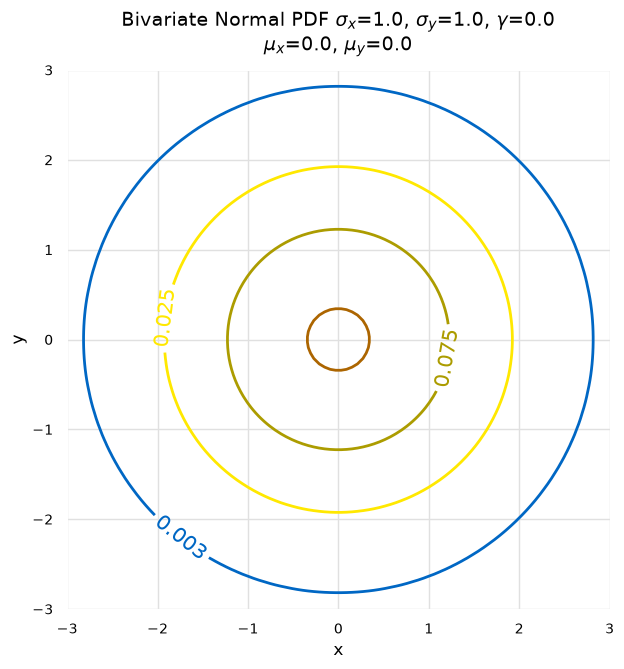

In [3]:
mean = numpy.array([0.0, 0.0])
cov = numpy.array([[1.0, 0.0], 
                  [0.0, 1.0]])
npts = 100
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

title = f"Bivariate Normal PDF $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
contour(pdf, x, y, numpy.array([0.003, 0.025, 0.075, 0.15]), title=title, title_offset=0.02)

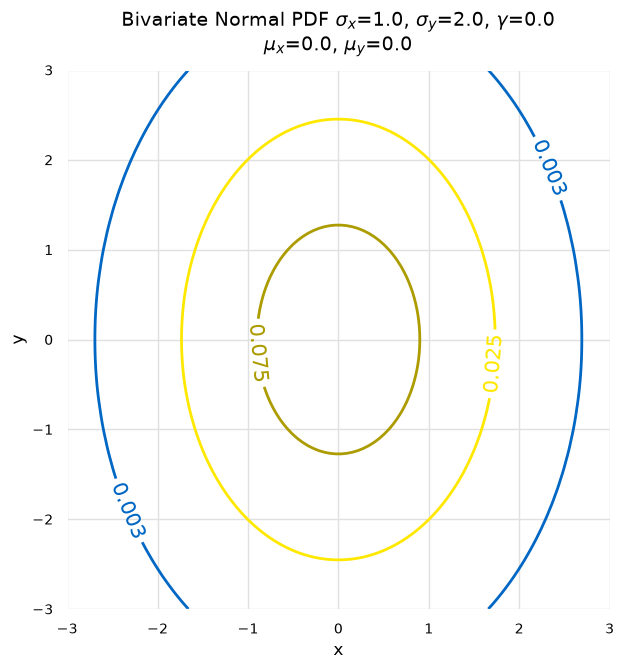

In [4]:
mean = numpy.array([0.0, 0.0])
cov = numpy.array([[1.0, 0.0], 
                  [0.0, 2.0]])
npts = 100
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

title = f"Bivariate Normal PDF $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
contour(pdf, x, y, numpy.array([0.003, 0.025, 0.075, 0.15]), title=title, title_offset=0.02)

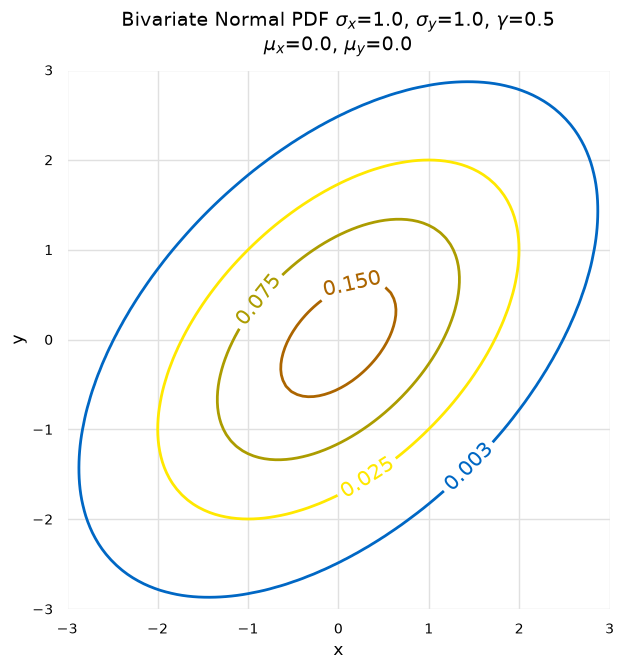

In [5]:
mean = numpy.array([0.0, 0.0])
cov = numpy.array([[1.0, 0.5], 
                  [0.5, 1.0]])
npts = 100
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

title = f"Bivariate Normal PDF $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
contour(pdf, x, y,  numpy.array([0.003, 0.025, 0.075, 0.15]), title=title, title_offset=0.02)

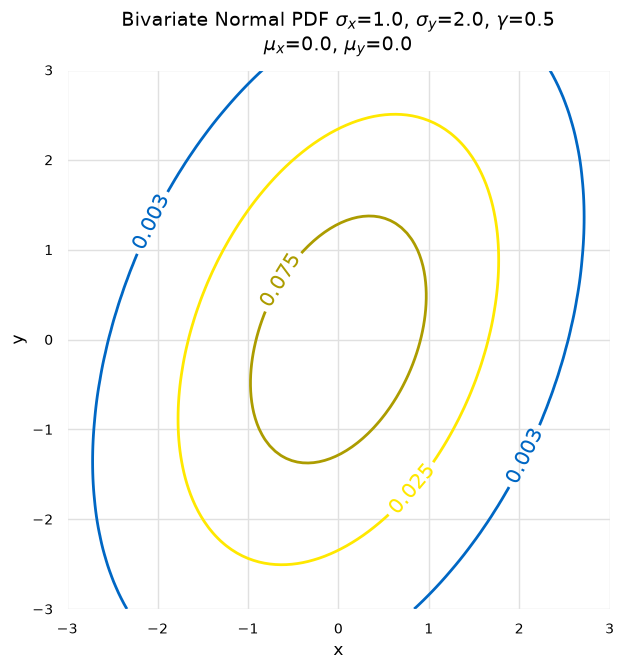

In [6]:
mean = numpy.array([0.0, 0.0])
cov = numpy.array([[1.0, 0.5], 
                  [0.5, 2.0]])
npts = 100
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

title = f"Bivariate Normal PDF $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
contour(pdf, x, y, numpy.array([0.003, 0.025, 0.075, 0.15]), title=title, title_offset=0.02)

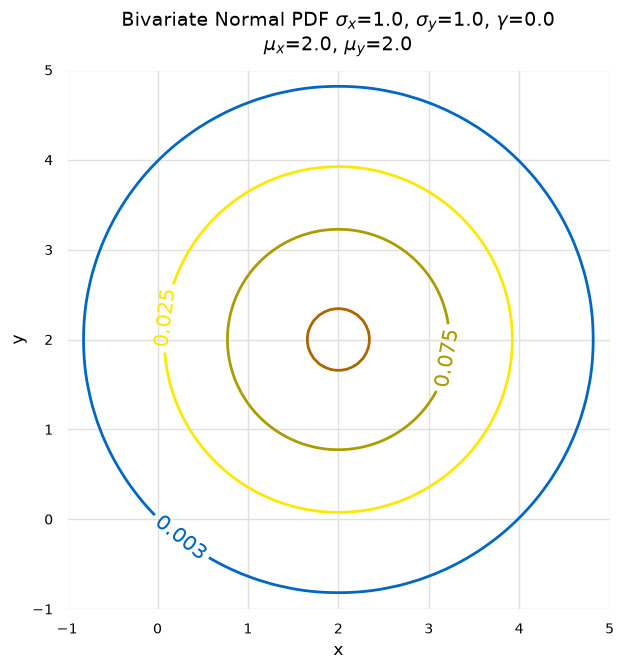

In [7]:
mean = numpy.array([2.0, 2.0])
cov = numpy.array([[1.0, 0.0], 
                  [0.0, 1.0]])
npts = 100
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

title = f"Bivariate Normal PDF $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
contour(pdf, x, y, numpy.array([0.003, 0.025, 0.075, 0.15]), title=title, title_offset=0.02)

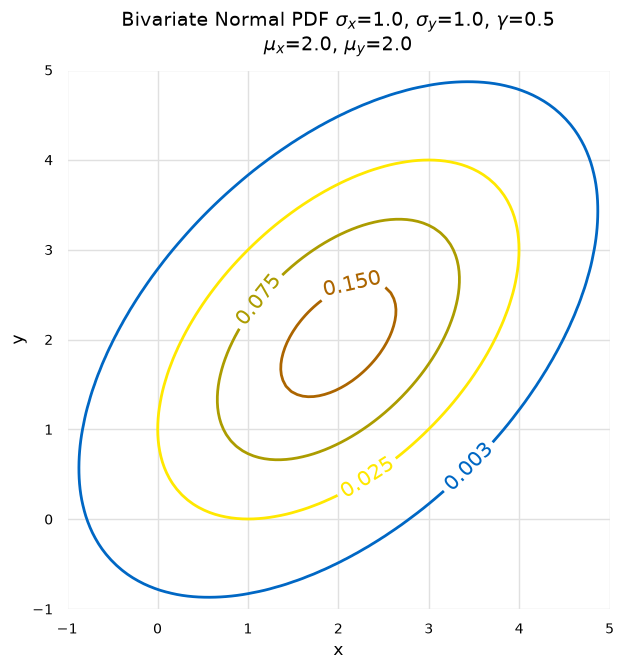

In [8]:
mean = numpy.array([2.0, 2.0])
cov = numpy.array([[1.0, 0.5], 
                  [0.5, 1.0]])
npts = 100
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

title = f"Bivariate Normal PDF $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
contour(pdf, x, y, numpy.array([0.003, 0.025, 0.075, 0.15]), title=title, title_offset=0.02)

## Bivariate Normal Simulations

### No Correlation and Equal Variances

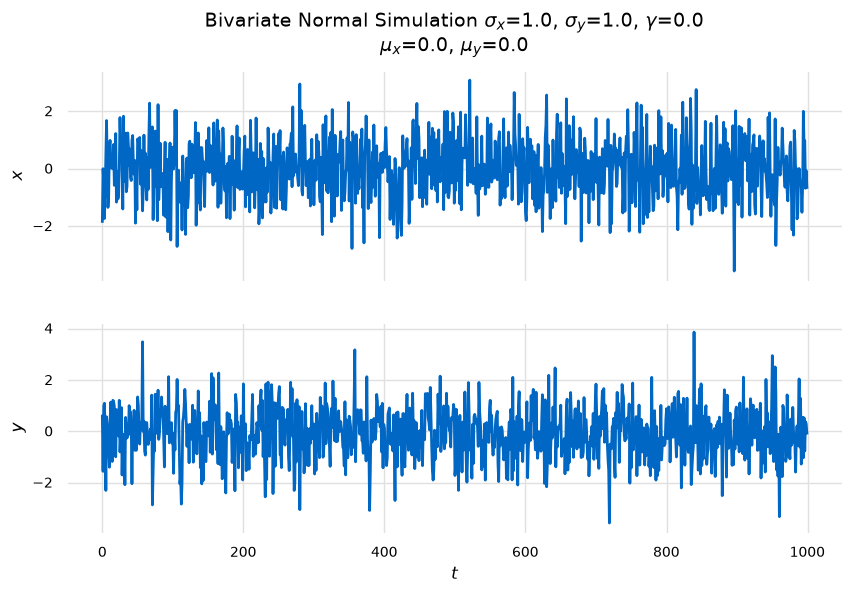

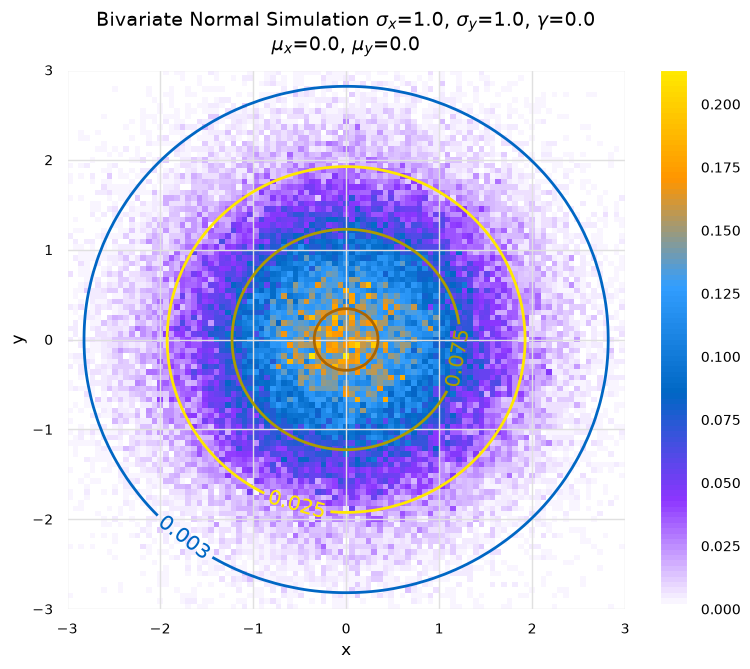

In [9]:
mean = numpy.array([0.0, 0.0])
cov = numpy.array([[1.0, 0.0], 
                   [0.0, 1.0]])
npts = 100
nsample = 100000
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

nsample = 100000
samples = stats.create_multivariate_normal_samples_source(mean, cov, nsample)

title = f"Bivariate Normal Simulation $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
stack([samples[0,0:1000], samples[1,0:1000]], title=title, xlabel=r"$t$", ylabels=[r"$x$", r"$y$"])
contour_hist(samples, pdf, x, y, numpy.array([0.003, 0.025, 0.075, 0.15]), title=title, title_offset=0.02)

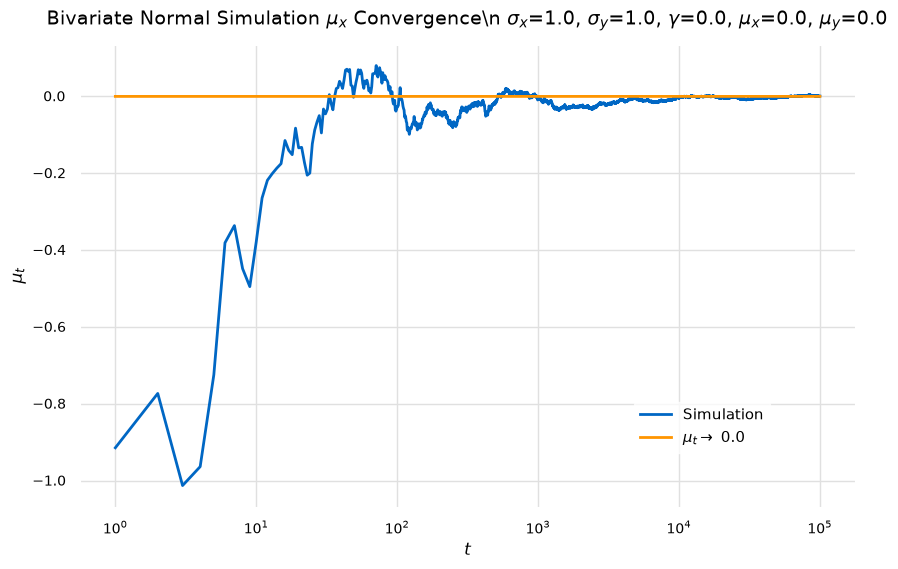

In [10]:
title = f"Bivariate Normal Simulation $\\mu_x$ Convergence\\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_mean_plot(samples[0], mean[0], title)

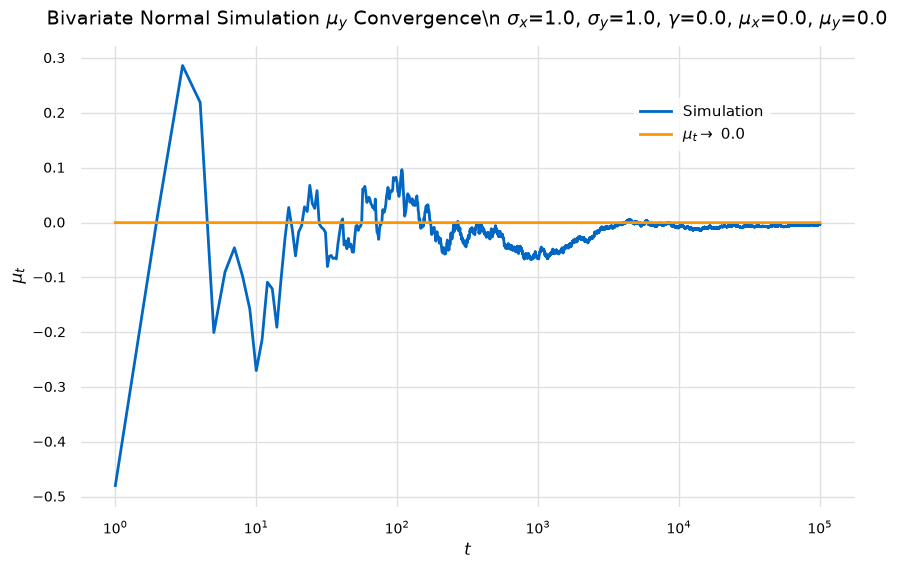

In [11]:
title = f"Bivariate Normal Simulation $\\mu_y$ Convergence\\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_mean_plot(samples[1], mean[1], title)

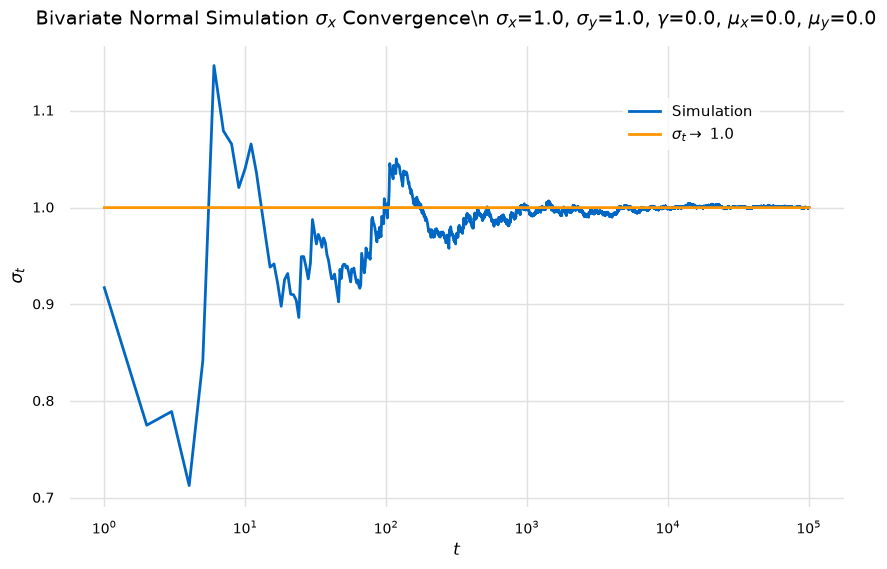

In [12]:
title = f"Bivariate Normal Simulation $\\sigma_x$ Convergence\\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_sd_plot(samples[0], numpy.sqrt(cov[0,0]), title)

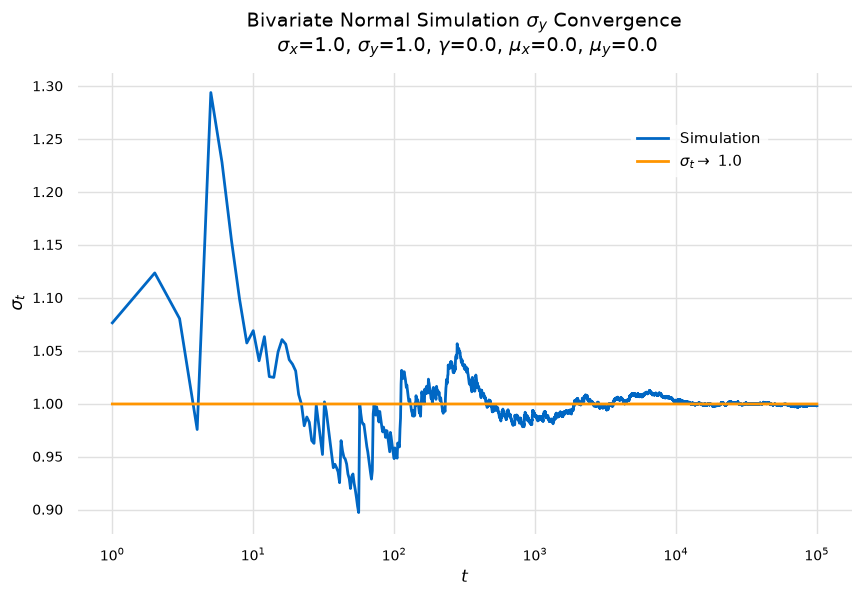

In [13]:
title = f"Bivariate Normal Simulation $\\sigma_y$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_sd_plot(samples[1], numpy.sqrt(cov[0,0]), title)

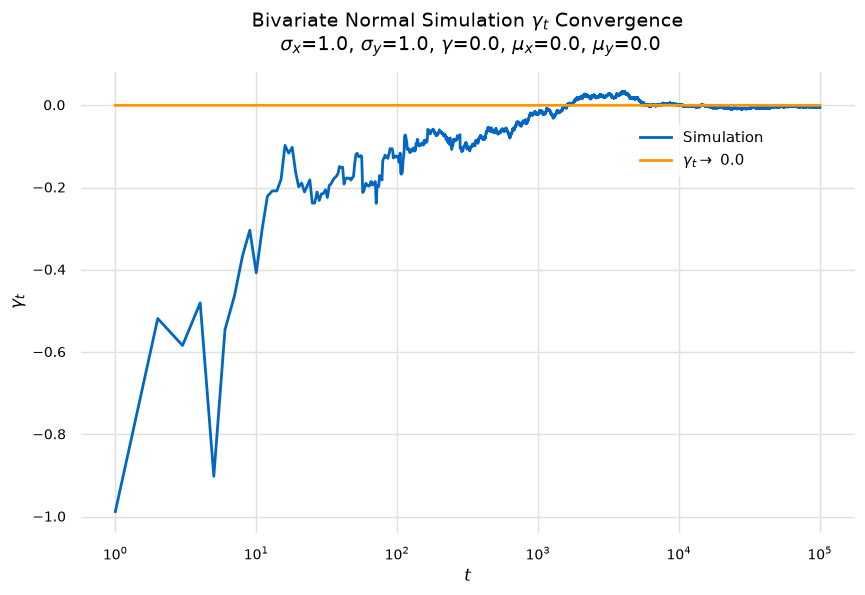

In [14]:
title = f"Bivariate Normal Simulation $\\gamma_t$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_cov_plot(samples[0], samples[1], cov[1,0], title)

### Correlation and Equal Variances

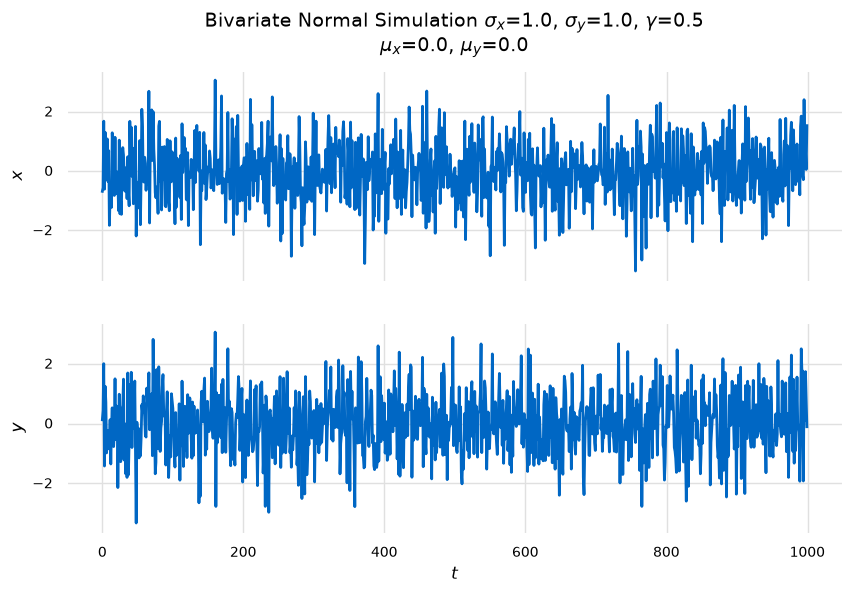

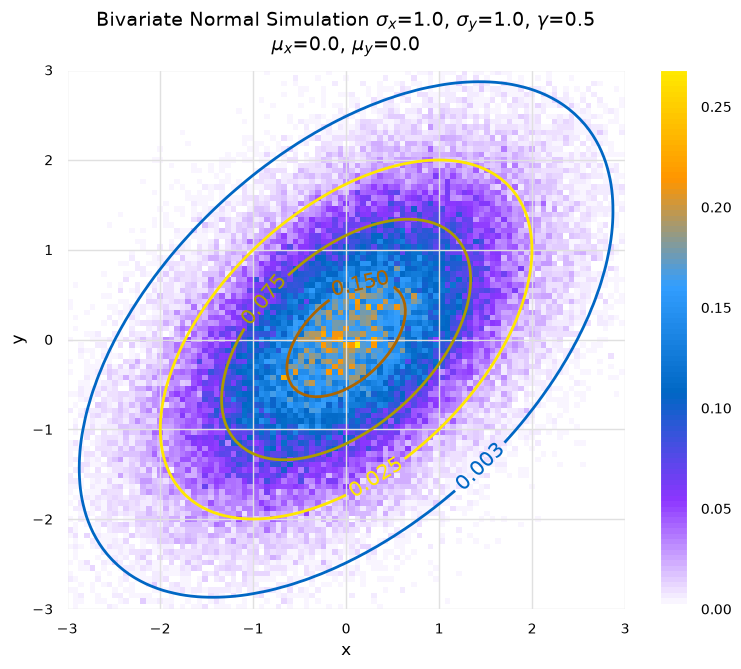

In [15]:
mean = numpy.array([0.0, 0.0])
cov = numpy.array([[1.0, 0.5], 
                   [0.5, 1.0]])
npts = 100
nsample = 100000
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

nsample = 100000
samples = stats.create_multivariate_normal_samples_source(mean, cov, nsample)

title = f"Bivariate Normal Simulation $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
stack([samples[0,0:1000], samples[1,0:1000]], title=title, xlabel=r"$t$", ylabels=[r"$x$", r"$y$"])
contour_hist(samples, pdf, x, y, [0.003, 0.025, 0.075, 0.15], title=title, title_offset=0.02)

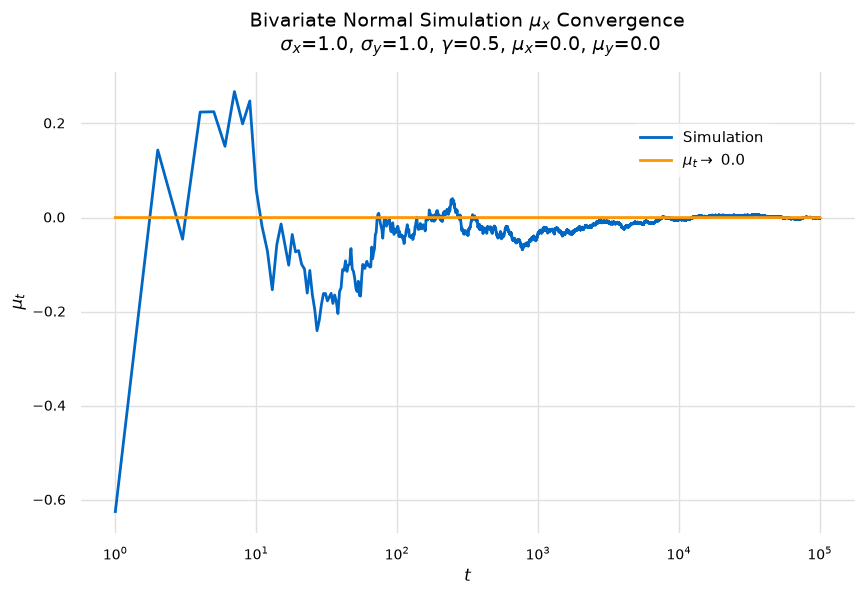

In [16]:
title = f"Bivariate Normal Simulation $\\mu_x$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_mean_plot(samples[0], mean[0], title)

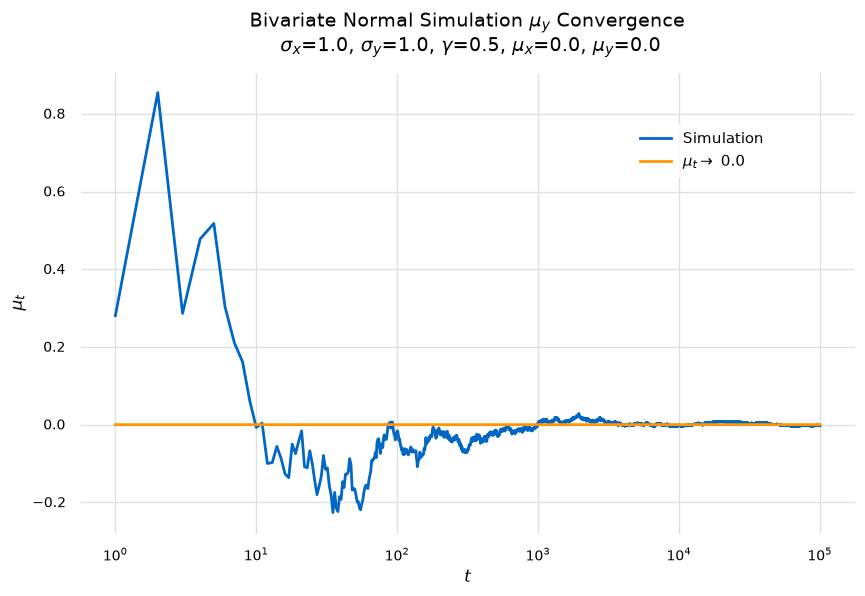

In [17]:
title = f"Bivariate Normal Simulation $\\mu_y$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_mean_plot(samples[1], mean[1], title)

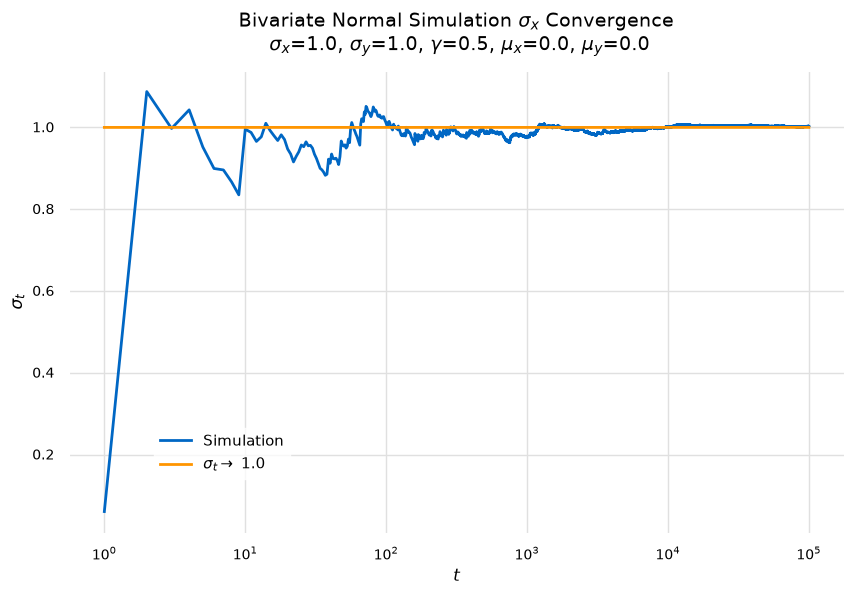

In [18]:
title = f"Bivariate Normal Simulation $\\sigma_x$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_sd_plot(samples[0], numpy.sqrt(cov[0,0]), title)

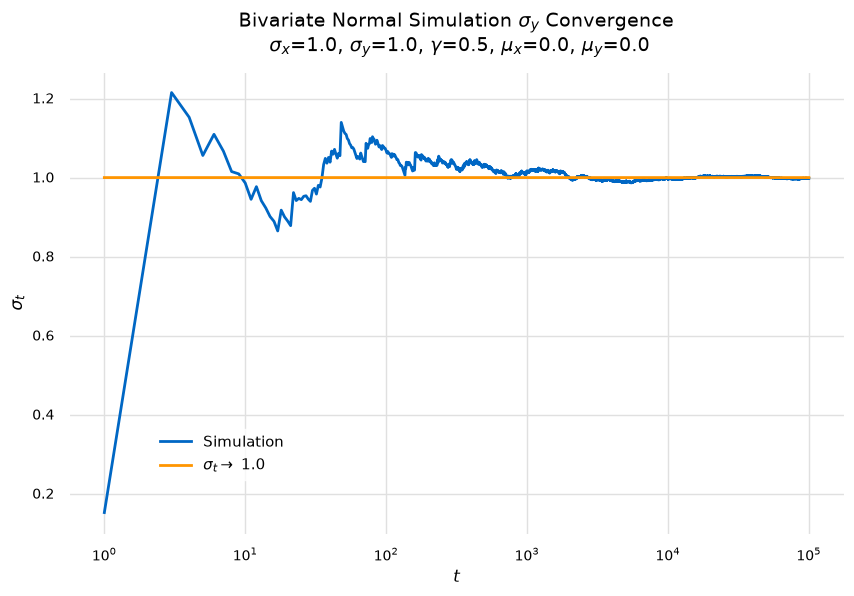

In [19]:
title = f"Bivariate Normal Simulation $\\sigma_y$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_sd_plot(samples[1], numpy.sqrt(cov[0,0]), title)

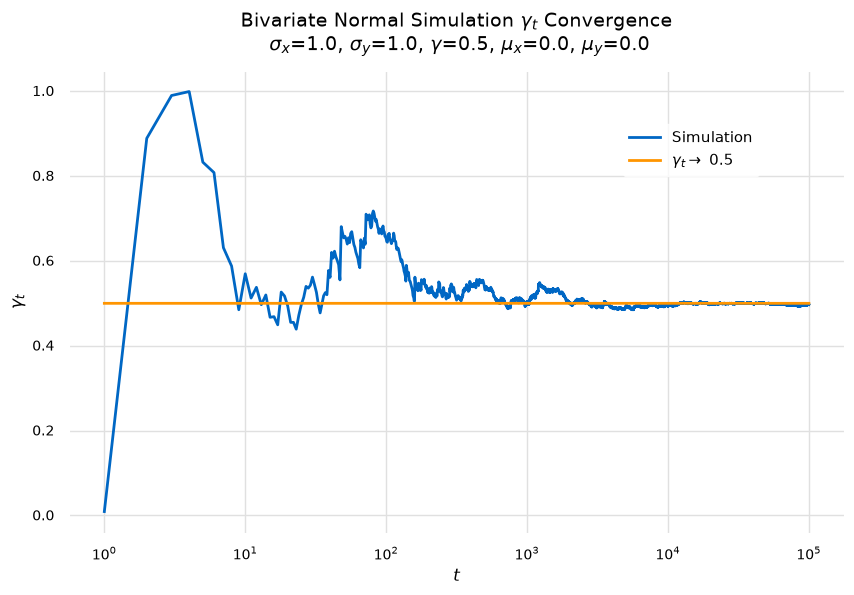

In [20]:
title = f"Bivariate Normal Simulation $\\gamma_t$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_cov_plot(samples[0], samples[1], cov[1,0], title)

### No Correlation and Unequal Variances

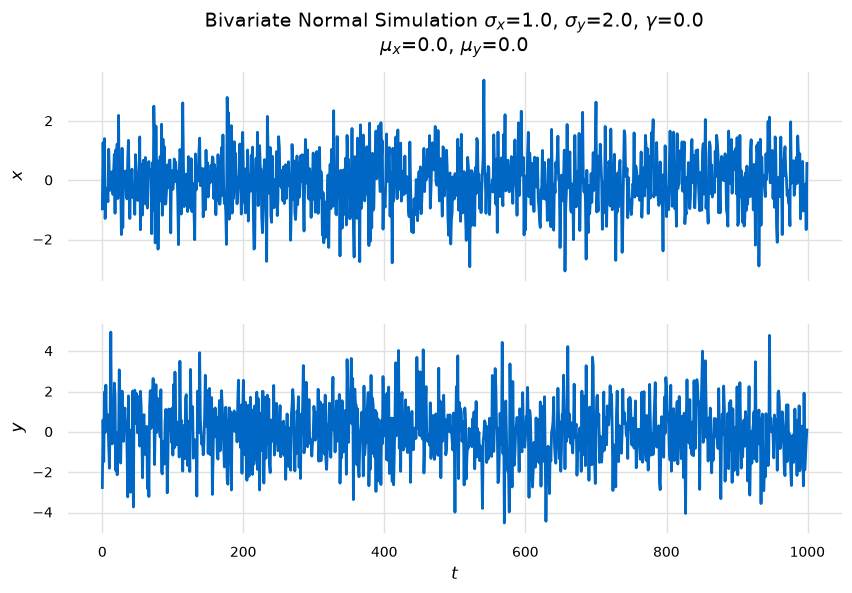

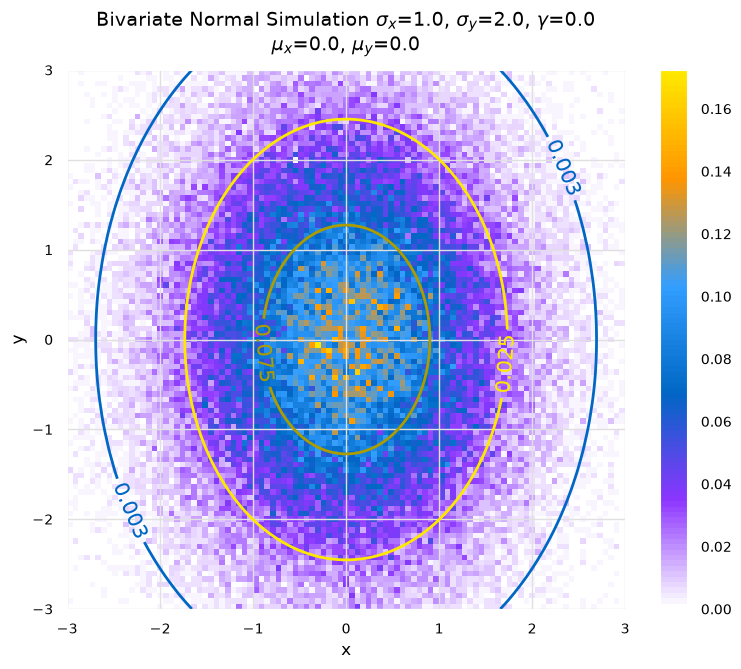

In [21]:
mean = numpy.array([0.0, 0.0])
cov = numpy.array([[1.0, 0.0], 
                   [0.0, 2.0]])
npts = 100
nsample = 100000
xy, pdf = stats.compute_multivariate_normal_pdf(mean, cov, npts)
x, y = xy

nsample = 100000
samples = stats.create_multivariate_normal_samples_source(mean, cov, nsample)

title = f"Bivariate Normal Simulation $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}\n$\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
stack([samples[0,0:1000], samples[1,0:1000]], title=title, xlabel=r"$t$", ylabels=[r"$x$", r"$y$"])
contour_hist(samples, pdf, x, y, [0.003, 0.025, 0.075, 0.15], title=title, title_offset=0.02)

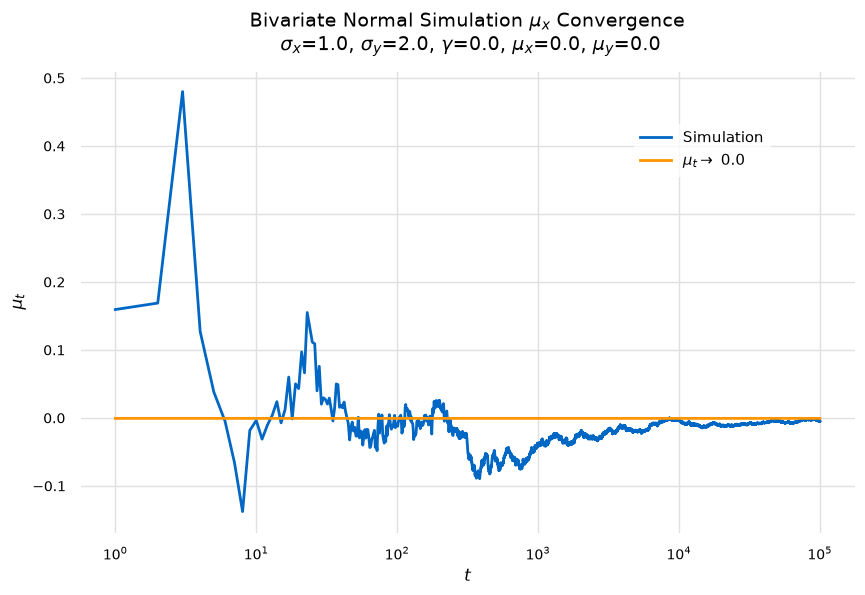

In [22]:
title = f"Bivariate Normal Simulation $\\mu_x$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_mean_plot(samples[0], mean[0], title)

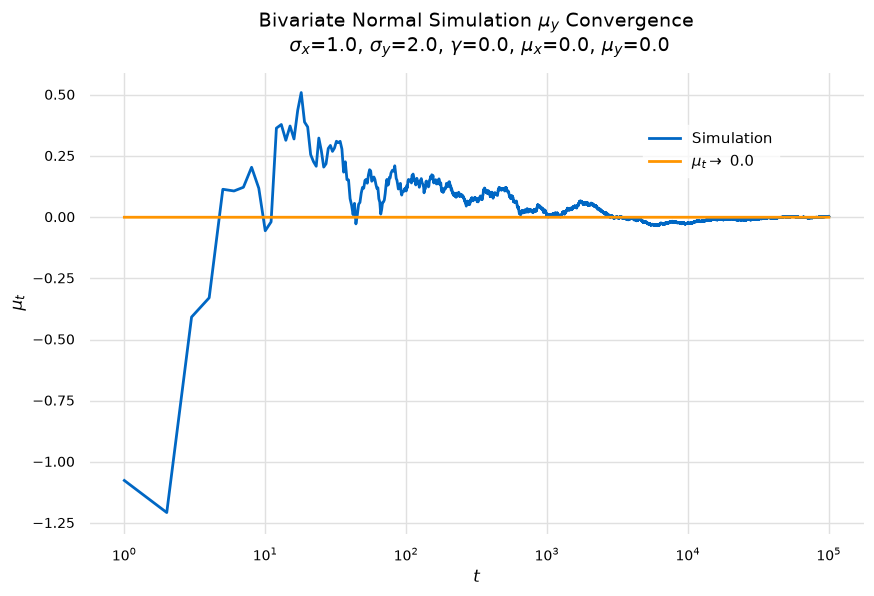

In [23]:
title = f"Bivariate Normal Simulation $\\mu_y$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_mean_plot(samples[1], mean[1], title)

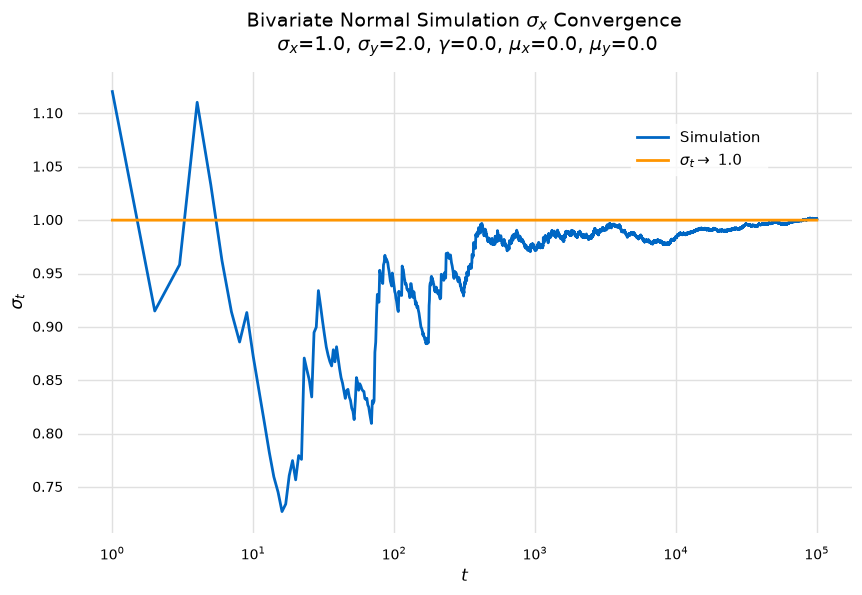

In [24]:
title = f"Bivariate Normal Simulation $\\sigma_x$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_sd_plot(samples[0], numpy.sqrt(cov[0,0]), title)

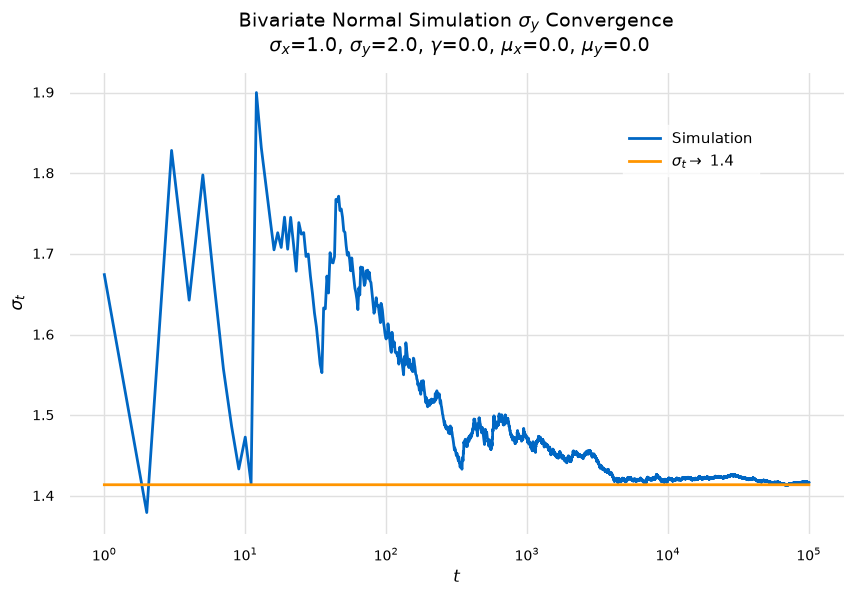

In [25]:
title = f"Bivariate Normal Simulation $\\sigma_y$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_sd_plot(samples[1], numpy.sqrt(cov[1,1]), title)

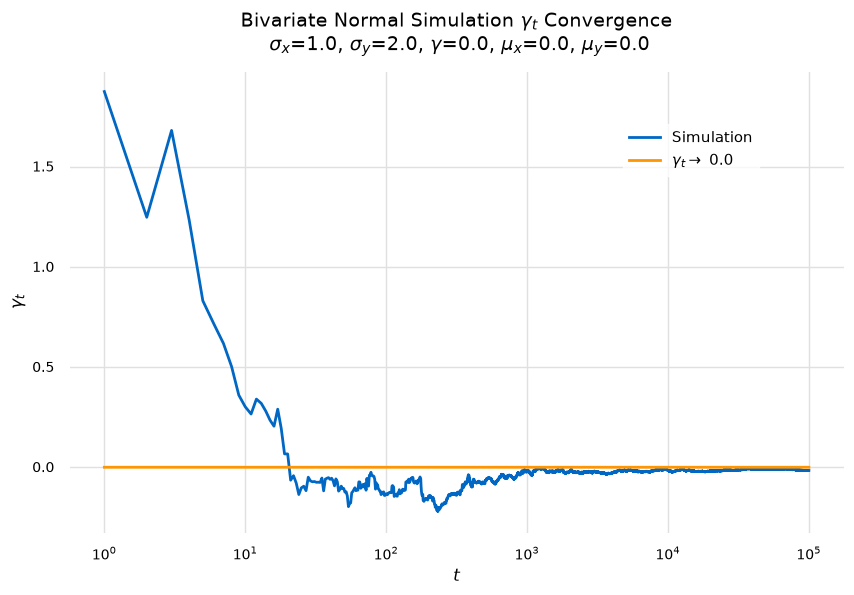

In [26]:
title = f"Bivariate Normal Simulation $\\gamma_t$ Convergence\n $\\sigma_x$={cov[0,0]}, $\\sigma_y$={cov[1,1]}, $\\gamma$={cov[1,0]}, $\\mu_x$={mean[0]}, $\\mu_y$={mean[1]}"
cumu_cov_plot(samples[0], samples[1], cov[1,0], title)